In [3]:
import torch
import torch.nn as nn
import torch.optim as optim
from torch.utils.data import DataLoader, random_split
from torchvision import datasets, transforms
import timm
import os

# For progress bars
from tqdm import tqdm

In [4]:
import os
import shutil

# --- Configuration ---

# 1. SET YOUR SOURCE FOLDER:
# Find your dataset path in the "Input" section of your notebook's sidebar.
# It will look something like '/kaggle/input/your-dataset-name' or 
# '/kaggle/input/your-dataset-name/images'
SOURCE_FOLDER = '/kaggle/input/melspectds/mel_images' # <-- CHANGE THIS

# 2. SET YOUR DESTINATION FOLDER:
# This will be created in your '/kaggle/working/' directory.
# You can see this in the "Output" section.
DESTINATION_BASE_FOLDER = '/kaggle/working/organized_images'

# --- End Configuration ---

# Create the base destination folder if it doesn't exist
os.makedirs(DESTINATION_BASE_FOLDER, exist_ok=True)
print(f"Organizing files from: {SOURCE_FOLDER}")
print(f"Saving to:           {DESTINATION_BASE_FOLDER}\n")

# Check if the source folder exists
if not os.path.exists(SOURCE_FOLDER):
    print(f"🚨 ERROR: Source folder not found: {SOURCE_FOLDER}")
    print("Please double-check your dataset path in the 'Input' sidebar.")
else:
    # Iterate over all entries in the source folder
    for entry in os.scandir(SOURCE_FOLDER):
        if not entry.is_file():
            continue
            
        filename = entry.name
        
        # Check for image extensions
        if not (filename.lower().endswith('.png') or 
                filename.lower().endswith('.jpg') or 
                filename.lower().endswith('.jpeg')):
            print(f"Skipping non-image file: {filename}")
            continue

        try:
            # Get filename without extension, e.g., "img_1000_14_1"
            base_name = os.path.splitext(filename)[0]
            
            # Split by underscore, e.g., ["img", "1000", "14", "1"]
            parts = base_name.split('_')
            
            # The class number is the 3rd part (index 2)
            class_number = parts[2]
            
            # Define the destination folder name, e.g., "class_14"
            dest_folder_name = f"class_{class_number}"
            dest_path = os.path.join(DESTINATION_BASE_FOLDER, dest_folder_name)
            
            # Create the destination class folder if it doesn't exist
            os.makedirs(dest_path, exist_ok=True)
            
            # Get the full old and new paths for the file
            source_file_path = entry.path
            dest_file_path = os.path.join(dest_path, filename)
            
            # *** KEY KAGGLE CHANGE ***
            # Use shutil.copy() because /kaggle/input is READ-ONLY.
            # We cannot 'move' files, we must 'copy' them to /kaggle/working.
            shutil.copy(source_file_path, dest_file_path)
            # print(f"Copied: {filename}  ->  {dest_folder_name}")

        except IndexError:
            # This handles files that don't match the "img_1000_14_1" format
            print(f"Skipping file (mismatched format): {filename}")
        except Exception as e:
            # Catch other potential errors
            print(f"Error processing {filename}: {e}")

    print("\n✅ File organization complete.")

Organizing files from: /kaggle/input/melspectds/mel_images
Saving to:           /kaggle/working/organized_images


✅ File organization complete.


In [ ]:
!pip install timm

In [12]:
# --- 1. Configuration (Same as before) ---
DATA_DIR = '/kaggle/working/organized_images'
IMG_SIZE = 224
BATCH_SIZE = 32
EPOCHS = 25  # You may want to start with 25-30 epochs
LR = 1e-4
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print(f"Using device: {device}")


# --- 2. Define Data Transforms (Same as before) ---
data_transforms = {
    'train': transforms.Compose([
        transforms.Resize((IMG_SIZE, IMG_SIZE)),
        transforms.RandomHorizontalFlip(),
        transforms.RandomRotation(10),
        transforms.ToTensor(),
        transforms.Normalize(mean=[0.485, 0.456, 0.406],
                             std=[0.229, 0.224, 0.225])
    ]),
    'val': transforms.Compose([
        transforms.Resize((IMG_SIZE, IMG_SIZE)),
        transforms.ToTensor(),
        transforms.Normalize(mean=[0.485, 0.456, 0.406],
                             std=[0.229, 0.224, 0.225])
    ]),
}

# --- 3. Load Dataset (The Fix is here) ---

# First, create the full dataset *without any transforms*
full_dataset_no_transform = datasets.ImageFolder(DATA_DIR)

# Get class info
num_classes = len(full_dataset_no_transform.classes)
class_names = full_dataset_no_transform.classes
print(f"Found {num_classes} classes: {class_names}")

# Split the dataset using random_split (this gives you Subset objects)
train_size = int(0.8 * len(full_dataset_no_transform))
val_size = len(full_dataset_no_transform) - train_size
train_subset, val_subset = random_split(full_dataset_no_transform, [train_size, val_size])

# --- 4. Create a Helper Class to Apply Transforms ---
# This wrapper class ensures the correct transform is applied
# to the correct subset (train or val)
class TransformedSubset(torch.utils.data.Dataset):
    def __init__(self, subset, transform):
        self.subset = subset
        self.transform = transform
    
    def __getitem__(self, index):
        # Get the original image and label from the subset
        x, y = self.subset[index]
        # Apply the transform
        if self.transform:
            x = self.transform(x)
        return x, y
    
    def __len__(self):
        return len(self.subset)

# --- 5. Create the final train and val datasets ---
# Now, we wrap our subsets with the helper class
train_dataset = TransformedSubset(train_subset, data_transforms['train'])
val_dataset = TransformedSubset(val_subset, data_transforms['val'])

# --- 6. Create DataLoaders (Same as before) ---
train_loader = DataLoader(train_dataset, batch_size=BATCH_SIZE, shuffle=True, num_workers=2)
val_loader = DataLoader(val_dataset, batch_size=BATCH_SIZE, shuffle=False, num_workers=2)

print(f"\nTraining set size: {len(train_dataset)} images")
print(f"Validation set size: {len(val_dataset)} images")

Using device: cuda
Found 27 classes: ['class_1', 'class_10', 'class_11', 'class_12', 'class_13', 'class_14', 'class_15', 'class_16', 'class_17', 'class_18', 'class_19', 'class_2', 'class_20', 'class_21', 'class_22', 'class_23', 'class_24', 'class_25', 'class_26', 'class_27', 'class_3', 'class_4', 'class_5', 'class_6', 'class_7', 'class_8', 'class_9']

Training set size: 1620 images
Validation set size: 405 images


In [13]:
model = timm.create_model(
    'swin_base_patch4_window7_224', # <-- NEW
    pretrained=True,
    num_classes=num_classes  # This automatically replaces the head
)

# Move the model to the GPU
model = model.to(device)

print("Loaded SWIN Transformer model.")

Loaded SWIN Transformer model.


In [14]:
# Loss function
criterion = nn.CrossEntropyLoss()

# Optimizer
# AdamW is the preferred optimizer for Transformer models
optimizer = optim.AdamW(model.parameters(), lr=LR)

# --- ADD THIS ---
# Add a learning rate scheduler as discussed
scheduler = optim.lr_scheduler.ReduceLROnPlateau(optimizer, 
                                                 mode='min',    # It monitors the val_loss
                                                 factor=0.1,    # Reduce LR by 10x
                                                 patience=3,    # Wait 3 epochs of no improvement
                                                 verbose=True)
# ---

In [15]:
print("Starting training...")

# --- ADD THESE LISTS ---
# To store loss values for plotting
train_loss_history = []
val_loss_history = []
train_acc_history = []
val_acc_history = []
# ---

for epoch in range(EPOCHS):
    # --- Training Phase ---
    model.train()
    running_loss = 0.0
    running_corrects = 0
    train_pbar = tqdm(train_loader, desc=f"Epoch {epoch+1}/{EPOCHS} [Train]")
    
    for inputs, labels in train_pbar:
        # ... (rest of the training loop) ...
        inputs = inputs.to(device)
        labels = labels.to(device)
        
        optimizer.zero_grad()
        outputs = model(inputs)
        _, preds = torch.max(outputs, 1)
        loss = criterion(outputs, labels)
        loss.backward()
        optimizer.step()

        running_loss += loss.item() * inputs.size(0)
        running_corrects += torch.sum(preds == labels.data)
        train_pbar.set_postfix({'loss': loss.item()})
        
    train_loss = running_loss / len(train_dataset)
    train_acc = running_corrects.double() / len(train_dataset)

    # --- Validation Phase ---
    model.eval()
    val_running_loss = 0.0
    val_running_corrects = 0
    val_pbar = tqdm(val_loader, desc=f"Epoch {epoch+1}/{EPOCHS} [Val]")

    with torch.no_grad():
        for inputs, labels in val_pbar:
            # ... (rest of the validation loop) ...
            inputs = inputs.to(device)
            labels = labels.to(device)

            outputs = model(inputs)
            _, preds = torch.max(outputs, 1)
            loss = criterion(outputs, labels)

            val_running_loss += loss.item() * inputs.size(0)
            val_running_corrects += torch.sum(preds == labels.data)
            val_pbar.set_postfix({'loss': loss.item()})

    val_loss = val_running_loss / len(val_dataset)
    val_acc = val_running_corrects.double() / len(val_dataset)

    print(f"Epoch {epoch+1}/{EPOCHS}")
    print(f"Train Loss: {train_loss:.4f} Acc: {train_acc:.4f}")
    print(f"Val   Loss: {val_loss:.4f} Acc: {val_acc:.4f}")
    
    scheduler.step(val_loss)
    print("-" * 20)

    # --- ADD THESE LINES TO SAVE THE VALUES ---
    train_loss_history.append(train_loss)
    train_acc_history.append(train_acc.item()) # Use .item() to get Python number
    val_loss_history.append(val_loss)
    val_acc_history.append(val_acc.item()) # Use .item() to get Python number
    # ---

print("✅ Training complete.")

Starting training...


Epoch 1/25 [Val]: 100%|██████████| 13/13 [00:05<00:00,  2.24it/s, loss=2.06]


Epoch 1/25
Train Loss: 2.2560 Acc: 0.3327
Val   Loss: 1.4785 Acc: 0.5407
--------------------


Epoch 2/25 [Val]: 100%|██████████| 13/13 [00:05<00:00,  2.18it/s, loss=1.21]


Epoch 2/25
Train Loss: 1.1390 Acc: 0.6093
Val   Loss: 0.9379 Acc: 0.7235
--------------------


...

Epoch 23/25
Train Loss: 0.0316 Acc: 0.9914
Val   Loss: 0.6204 Acc: 0.8198
--------------------


Epoch 24/25 [Val]: 100%|██████████| 13/13 [00:06<00:00,  2.16it/s, loss=0.834]


Epoch 24/25
Train Loss: 0.0304 Acc: 0.9926
Val   Loss: 0.6204 Acc: 0.8198
--------------------


Epoch 25/25 [Val]: 100%|██████████| 13/13 [00:05<00:00,  2.17it/s, loss=0.834]

Epoch 25/25
Train Loss: 0.0294 Acc: 0.9932
Val   Loss: 0.6204 Acc: 0.8198
--------------------
✅ Training complete.


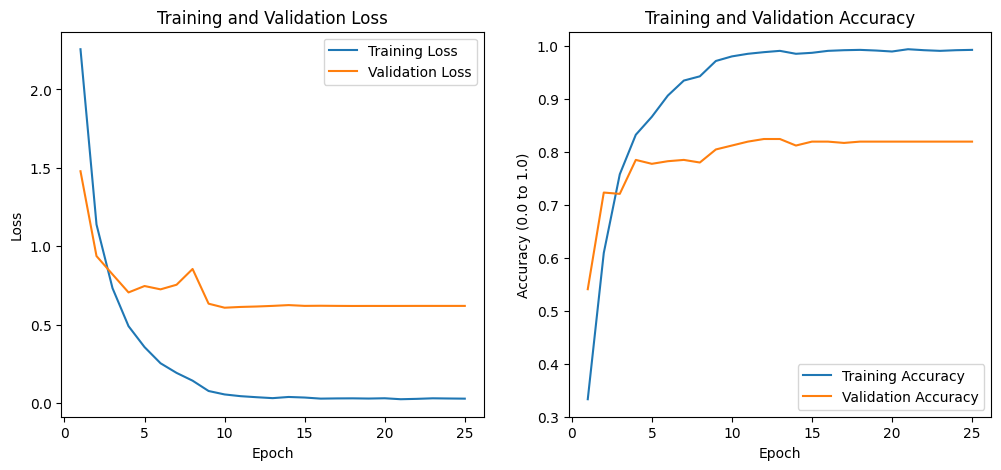

In [16]:
import matplotlib.pyplot as plt

# Get the number of epochs
epochs_range = range(1, EPOCHS + 1)

# Plot Training & Validation Loss
plt.figure(figsize=(12, 5))

# Plot Loss
plt.subplot(1, 2, 1)
plt.plot(epochs_range, train_loss_history, label='Training Loss')
plt.plot(epochs_range, val_loss_history, label='Validation Loss')
plt.legend(loc='upper right')
plt.title('Training and Validation Loss')
plt.xlabel('Epoch')
plt.ylabel('Loss')

# Plot Accuracy
plt.subplot(1, 2, 2)
plt.plot(epochs_range, train_acc_history, label='Training Accuracy')
plt.plot(epochs_range, val_acc_history, label='Validation Accuracy')
plt.legend(loc='lower right')
plt.title('Training and Validation Accuracy')
plt.xlabel('Epoch')
plt.ylabel('Accuracy (0.0 to 1.0)')

# Save the figure (optional, but good for Kaggle)
# You can find the file in the "Output" section
plt.savefig('training_plots.png')

# Show the plot
plt.show()